# EDA in pandas and duckdb for Stockholm cultural events (Metrics and KPI) 

In [3]:
# Import (Pandas + DuckDB + Matplotlib)

import pandas as pd
import duckdb
import matplotlib.pyplot as plt

In [4]:
# Load data and quick checks/exploration of dataset

df = pd.read_csv("app/data/output/events_full_year.csv")

df.head()


,event_id,name,url,image_url,date,time,status,segment,genre,subgenre,venue_name,venue_city,venue_address,venue_lat,venue_lon,day_of_week,month_name,month_num,year,hour
0,Z698xZq2Z1k-Fudb3,Svartklubben - Mat & Musik i Mörker,https://www.ticketmaster.se/event/svartklubben...,https://s1.ticketm.net/dam/a/841/1c1b2a57-616a...,2026-04-14,18:00,onsale,Miscellaneous,Food & Drink,Restaurant,Svartklubben,Stockholm,Södermannagatan 27,59.31209,18.08133,Tuesday,April,4,2026,18
1,Z698xZq2Z1k37ef-A,Eric Idle,https://www.ticketmaster.se/event/eric-idle-al...,https://s1.ticketm.net/dam/e/d88/0cbf49c5-f18e...,2026-04-14,19:00,onsale,Arts & Theatre,Theatre,Miscellaneous,Cirkus,Stockholm,Djurgårdsslätten 43-45,59.32457,18.09969,Tuesday,April,4,2026,19
2,Z698xZq2Z16vZ0G9_M,40 Fingers,https://www.ticketmaster.se/event/40-fingers-b...,https://s1.ticketm.net/dam/e/a38/c01c9483-250c...,2026-04-15,19:30,onsale,Music,Rock,Pop,Göta Lejon,Stockholm,Götgatan 55,59.31378,18.07384,Wednesday,April,4,2026,19
3,Z698xZq2Z16vavQaZx,Amanda Bergman,https://www.ticketmaster.se/event/amanda-bergm...,https://s1.ticketm.net/dam/a/da1/c489a12c-bab8...,2026-04-15,19:30,onsale,Music,Alternative,Indie Pop,Cirkus,Stockholm,Djurgårdsslätten 43-45,59.32457,18.09969,Wednesday,April,4,2026,19
4,Z698xZq2Z16va-0gjy,Svartklubben - Mat & Musik i Mörker,https://www.ticketmaster.se/event/svartklubben...,https://s1.ticketm.net/dam/a/841/1c1b2a57-616a...,2026-04-16,18:00,onsale,Arts & Theatre,Theatre,Miscellaneous,Svartklubben,Stockholm,Södermannagatan 27,59.31209,18.08133,Thursday,April,4,2026,18


In [5]:
df.describe()

,venue_lat,venue_lon,month_num,year,hour
count,633.000000,633.000000,633.000000,633.000000,633.000000
mean,59.379555,18.140393,7.206951,2026.048973,17.917852
std,0.182490,0.223740,2.992049,0.215983,2.813206
min,59.290450,18.000410,1.000000,2026.000000,0.000000
25%,59.313780,18.063640,5.000000,2026.000000,18.000000
50%,59.324570,18.080810,6.000000,2026.000000,19.000000
75%,59.336230,18.099690,10.000000,2026.000000,19.000000
max,59.993330,18.890620,12.000000,2027.000000,22.000000


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 633 entries, 0 to 632
Data columns (total 20 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   event_id       633 non-null    str    
 1   name           633 non-null    str    
 2   url            633 non-null    str    
 3   image_url      633 non-null    str    
 4   date           633 non-null    str    
 5   time           633 non-null    str    
 6   status         633 non-null    str    
 7   segment        633 non-null    str    
 8   genre          633 non-null    str    
 9   subgenre       633 non-null    str    
 10  venue_name     633 non-null    str    
 11  venue_city     633 non-null    str    
 12  venue_address  631 non-null    str    
 13  venue_lat      633 non-null    float64
 14  venue_lon      633 non-null    float64
 15  day_of_week    633 non-null    str    
 16  month_name     633 non-null    str    
 17  month_num      633 non-null    int64  
 18  year           633 no

## Connect duckdb (Duckdb sql for analysis ) 

In [7]:
con = duckdb.connect()
con.register("events", df)  #register table "events"in df for queries 

## Events per segment

In [8]:
events_per_segment= con.execute("""
    SELECT segment, COUNT(*) as total_events
    FROM events
    GROUP BY segment
    ORDER BY total_events DESC
    """).df()

events_per_segment

,segment,total_events
0,Arts & Theatre,425
1,Music,152
2,Miscellaneous,52
3,Sports,4


## Events per genre

In [9]:
events_per_game= con.execute("""
    SELECT genre, COUNT(*) as total_events
    FROM events
    GROUP BY genre
    ORDER BY total_events DESC
    """).df()

events_per_game

,genre,total_events
0,Theatre,232
1,Comedy,93
2,Dance,65
3,Rock,58
4,Other,38
5,Food & Drink,30
6,Hip-Hop/Rap,19
7,Family,19
8,Spectacular,12
9,Magic & Illusion,11


## Most repeated events(Top 10)

In [10]:
most_repeated_events= con.execute("""
    SELECT name, COUNT(*) AS occurrences
    FROM events
    GROUP BY name
    ORDER BY occurrences DESC
    LIMIT 10;
    """).df()

most_repeated_events


,name,occurrences
0,MAMMA MIA! THE PARTY,88
1,Torka aldrig tårar utan handskar,52
2,Svartklubben - Mat & Musik i Mörker,39
3,& Julia,34
4,Fredrik ”Benke” Rydman – Romeo & Julia,18
5,Labero's Magic World,14
6,Bo Kaspers Orkester - Il magnifico,12
7,Tomten är far till alla barnen,12
8,MAFFIA COMEDY SUPERWEEKEND,9
9,HippHipp Live!,8


## Visualization for most ocuurences

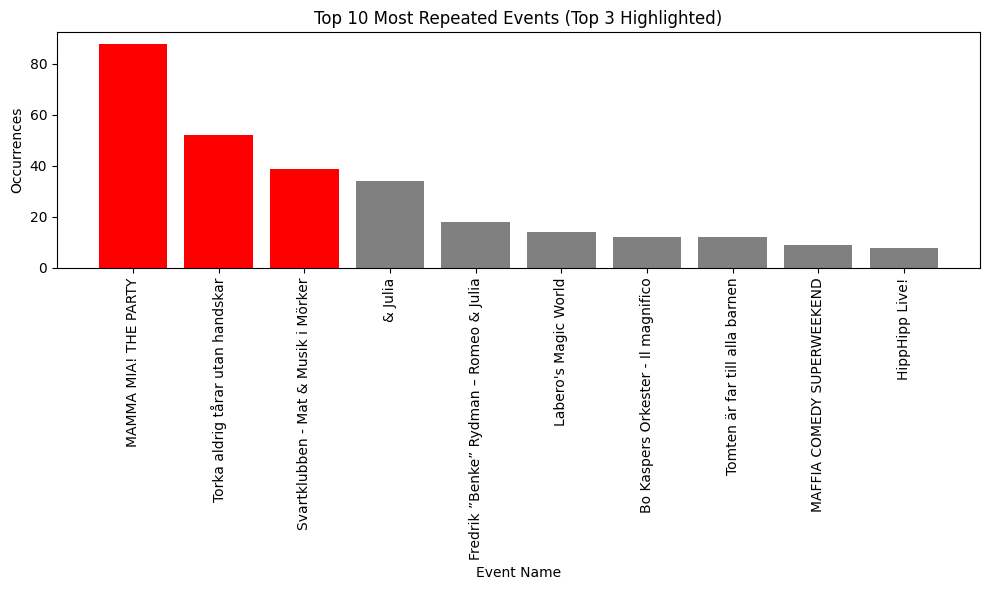

In [11]:
fig, ax = plt.subplots(figsize=(10,6))

# Sort data 
data = most_repeated_events.sort_values(by="occurrences", ascending=False)

# Top 3 events
top3 = data.head(3)["name"]

# Colors (highlight top 3)
colors = ["red" if name in top3.values else "grey"
          for name in data["name"]]

# Plot
ax.bar(data["name"], data["occurrences"], color=colors)

# Labels
ax.set_title("Top 10 Most Repeated Events (Top 3 Highlighted)")
ax.set_xlabel("Event Name")
ax.set_ylabel("Occurrences")
ax.tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.show()

## Top venues by event volume(Top 10)

In [12]:
top_venues_by_event_vol= con.execute("""
    SELECT venue_name, COUNT(*) AS total_events
    FROM events
    GROUP BY venue_name
    ORDER BY total_events DESC
    LIMIT 10;
    """).df()

top_venues_by_event_vol

,venue_name,total_events
0,Göta Lejon,95
1,Tyrol,90
2,Cirkus,89
3,Clarion Hotel Sign,51
4,Svartklubben,40
5,Dansens Hus - Stora Scen,33
6,Nya Cirkus,26
7,Strawberry Arena,25
8,Rival,22
9,Filadelfia Convention Center,20


## Visulization for top venues by venue

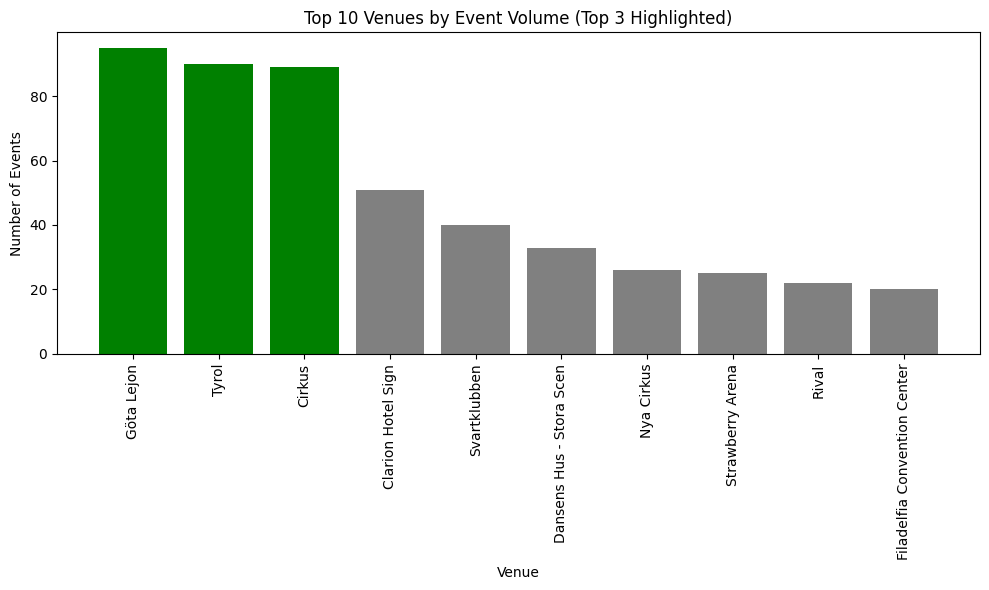

In [13]:
fig, ax = plt.subplots(figsize=(10,6))

# Sort data 
data = top_venues_by_event_vol.sort_values(by="total_events", ascending=False)

# Top 3 venues
top3 = data.head(3)["venue_name"]

# Colors (highlight top 3)
colors = ["green" if venue in top3.values else "grey"
          for venue in data["venue_name"]]

# Plot
ax.bar(data["venue_name"], data["total_events"], color=colors)

# Labels
ax.set_title("Top 10 Venues by Event Volume (Top 3 Highlighted)")
ax.set_xlabel("Venue")
ax.set_ylabel("Number of Events")
ax.tick_params(axis='x', rotation=90)


plt.tight_layout()
plt.show()

## Events by day of week

In [14]:
events_by_day_of_the_week= con.execute("""
    SELECT day_of_week, COUNT(*) AS total_events
    FROM events
    GROUP BY day_of_week
    ORDER BY total_events DESC;
    """).df()

events_by_day_of_the_week

,day_of_week,total_events
0,Saturday,246
1,Friday,145
2,Thursday,87
3,Sunday,52
4,Wednesday,45
5,Tuesday,34
6,Monday,24


## Events by month of the year 

In [15]:
events_by_month_of_year= con.execute("""
    SELECT month_name, COUNT(*) AS total_events
    FROM events
    GROUP BY month_name
    ORDER BY total_events DESC;
    """).df()

events_by_month_of_year

,month_name,total_events
0,May,156
1,April,106
2,October,90
3,November,77
4,December,46
5,September,45
6,June,43
7,August,30
8,July,16
9,January,13


## Segment - Genre breakdown

In [16]:
segment_genre= con.execute("""
    SELECT segment, genre, COUNT(*) AS total
    FROM events
    GROUP BY segment, genre
    ORDER BY total DESC;
    """).df()

segment_genre

,segment,genre,total
0,Arts & Theatre,Theatre,232
1,Arts & Theatre,Comedy,93
2,Arts & Theatre,Dance,65
3,Music,Rock,58
4,Music,Other,38
5,Miscellaneous,Food & Drink,30
6,Miscellaneous,Family,19
7,Music,Hip-Hop/Rap,19
8,Arts & Theatre,Spectacular,12
9,Arts & Theatre,Magic & Illusion,11


## Peak hours oveerall 

In [17]:
overall_peak_hours= con.execute("""
    SELECT hour, COUNT(*) AS total_events
    FROM events
    GROUP BY hour
    ORDER BY hour;
    """).df()

overall_peak_hours

,hour,total_events
0,0,7
1,1,1
2,11,10
3,12,1
4,13,20
5,14,7
6,15,46
7,16,26
8,17,15
9,18,125


## Filter events(names) with their segments and genre that occur in Strawberry Arena

In [18]:
events_in_strwb_arena=con.execute("""
   SELECT DISTINCT name, segment, genre
    FROM events
    WHERE venue_name = 'Strawberry Arena'
    """).df()

events_in_strwb_arena

,name,segment,genre
0,Bad Bunny - DeBÍ TiRAR MáS FOToS World Tour | ...,Music,Rock
1,Foo Fighters: TAKE COVER TOUR 2026 | Hotel Pac...,Music,Rock
2,The Weeknd: After Hours Til Dawn Tour | Strawb...,Music,Hip-Hop/Rap
3,Bad Bunny - DeBÍ TiRAR MáS FOToS World Tour | ...,Music,Latin
4,Bad Bunny - DeBÍ TiRAR MáS FOToS World Tour,Music,Latin
5,The Weeknd: After Hours Til Dawn Tour,Music,Other
6,Manchester United - Atlético De Madrid,Sports,Soccer
7,The Weeknd: After Hours Til Dawn Tour | VIP Pa...,Music,Hip-Hop/Rap
8,System Of A Down | Strawberry Arena Premium Ex...,Music,Metal
9,System Of A Down,Music,Rock


## Top 5 Genre 

In [19]:
top_5_genres = con.execute("""
    SELECT genre, COUNT(*) AS total_events
    FROM events
    GROUP BY genre
    ORDER BY total_events DESC
    LIMIT 5;
""").df()


top_5_genres

,genre,total_events
0,Theatre,232
1,Comedy,93
2,Dance,65
3,Rock,58
4,Other,38


## Visualization for top genres 

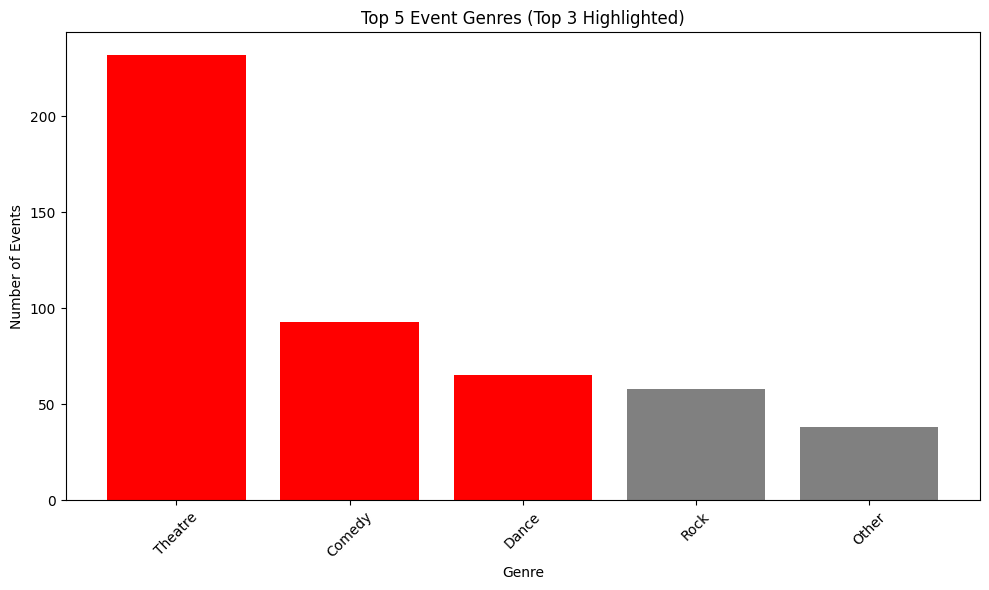

In [20]:
fig, ax = plt.subplots(figsize=(10,6))

# Sort data
data = top_5_genres.sort_values(by="total_events", ascending=False)

# Identify top 3
top3 = data.head(3)["genre"]

# Create colors
colors = ["red" if data in top3.values else "grey"
          for data in data["genre"]]

# Plot
ax.bar(data["genre"], data["total_events"], color=colors)

# Labels
ax.set_title("Top 5 Event Genres (Top 3 Highlighted)")
ax.set_xlabel("Genre")
ax.set_ylabel("Number of Events")
ax.tick_params(axis='x', rotation=45)


plt.tight_layout()
plt.show()

## Total number of events per month for the year 2026

In [22]:
events_2026_monthly = con.execute("""
    SELECT 
        month_num,
        month_name,
        COUNT(*) AS total_events
    FROM events
    WHERE year = 2026
    GROUP BY month_num, month_name
    ORDER BY month_num;
""").df()

events_2026_monthly

,month_num,month_name,total_events
0,4,April,102
1,5,May,154
2,6,June,43
3,7,July,16
4,8,August,30
5,9,September,45
6,10,October,90
7,11,November,77
8,12,December,45


## Line chart for Visualization 

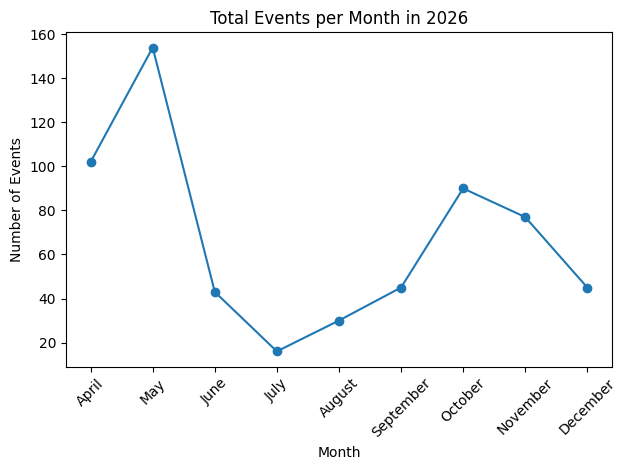

In [23]:


fig, ax = plt.subplots()

ax.plot(
    events_2026_monthly["month_name"],
    events_2026_monthly["total_events"],
    marker="o"
)

ax.set_title("Total Events per Month in 2026")
ax.set_xlabel("Month")
ax.set_ylabel("Number of Events")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()